# 15 — Neural Network Components: Activations, Losses, Optimisers, Init

**Prerequisite:** notebook 14 (the math).

This notebook covers *what you wire together* — the menu of choices that turn a
stack of dot products into a working model: **activation functions**, **loss
functions**, **optimisers**, **weight initialisation**, and **regularisation**.
Each comes with its own failure mode.

## What you'll understand after this notebook

1. Why we need **nonlinear activations** at all, and the trade-offs between
 ReLU, sigmoid, tanh, and their variants — including the **dying ReLU** failure.
2. How to **match the loss function to the task** (MSE, cross‑entropy, hinge…).
3. The optimiser zoo — **SGD → momentum → RMSprop → Adam** — what each adds and
 when to reach for it.
4. Why **initialisation matters** (He for ReLU, Xavier for tanh/sigmoid) and
 what breaks when you get it wrong.
5. The regularisation toolkit — **L2, dropout, early stopping, batch‑norm** —
 and which combats which kind of overfitting.

## How this notebook is organised

```mermaid
flowchart LR
 A["Activations<br/>nonlinearity + derivatives"] --> L
 L["Loss functions<br/>the training target"] --> O
 O["Optimisers<br/>SGD → Adam"] --> I
 I["Initialisation<br/>He / Xavier"] --> R
 R["Regularisation<br/>L2 / dropout / early-stop / batch-norm"]
```

## 1. Activation functions

### 1.1 Why we need them at all

Stack linear layers without activations and the whole net collapses to a single
linear function — no matter how deep:

$$W_2 (W_1 x + b_1) + b_2 = \underbrace{(W_2 W_1)}_{\text{just another matrix}}\, x + \text{const}$$

The nonlinearity is what gives nets their power (§6.2: it's the source of
the model's *capacity*). Pick it badly and you get vanishing gradients
(notebook 14 §4.2); pick it well and deep nets train smoothly.

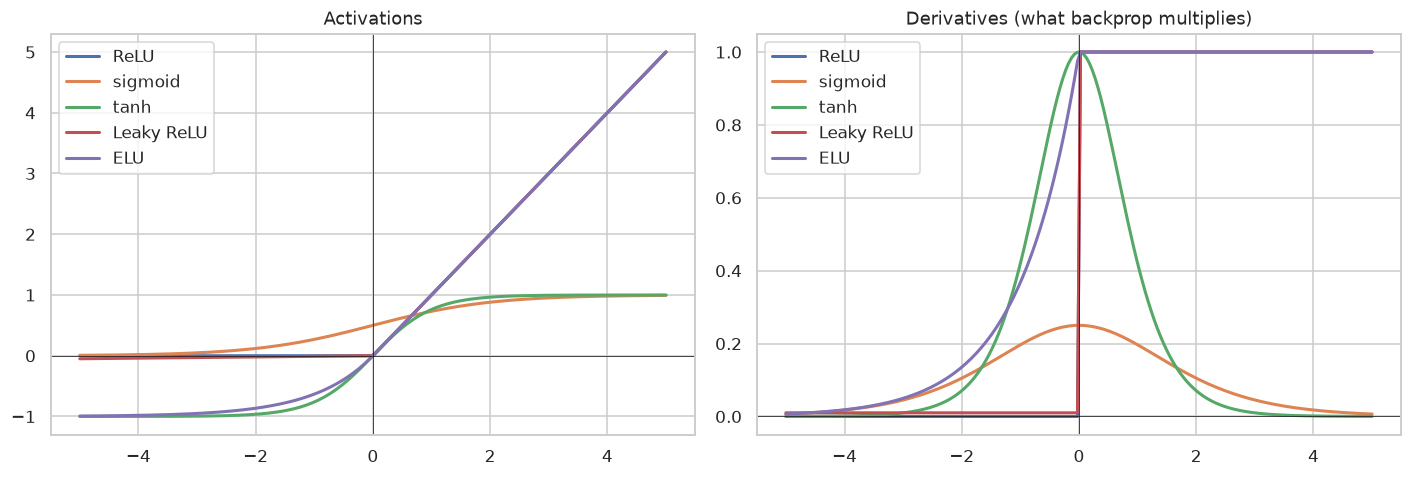

In [1]:
from setup import *

z = np.linspace(-5, 5, 200)
acts = {
 "ReLU": np.maximum(0, z),
 "sigmoid": 1 / (1 + np.exp(-z)),
 "tanh": np.tanh(z),
 "Leaky ReLU": np.where(z > 0, z, 0.01 * z),
 "ELU": np.where(z > 0, z, np.exp(z) - 1),
}
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for name, y in acts.items():
 ax[0].plot(z, y, lw=2, label=name)
ax[0].set_title("Activations")
ax[0].legend(); ax[0].axhline(0, color="k", lw=0.5); ax[0].axvline(0, color="k", lw=0.5)

# Their derivatives (what flows through backprop)
sig = 1 / (1 + np.exp(-z))
d_acts = {
 "ReLU": (z > 0).astype(float),
 "sigmoid": sig * (1 - sig),
 "tanh": 1 - np.tanh(z)**2,
 "Leaky ReLU": np.where(z > 0, 1, 0.01),
 "ELU": np.where(z > 0, 1, np.exp(np.minimum(z, 0))),
}
for name, dy in d_acts.items():
 ax[1].plot(z, dy, lw=2, label=name)
ax[1].set_title("Derivatives (what backprop multiplies)")
ax[1].legend(); ax[1].axhline(0, color="k", lw=0.5); ax[1].axvline(0, color="k", lw=0.5)
plt.tight_layout(); plt.show()

### 1.2 The four activations you'll meet

| Activation | Pros | Cons / failure |
|---|---|---|
| **Sigmoid** $\sigma(z) = 1/(1+e^{-z})$ | smooth, output in (0,1) | **vanishing gradient**: derivative peaks at 0.25; ×5 layers → ~0.001. Outputs not zero‑centred |
| **Tanh** $\tanh(z)$ | zero‑centred (better than sigmoid) | still saturates → vanishing in deep nets |
| **ReLU** $\max(0, z)$ | derivative is 0 or 1 → no vanishing; sparse; fast | **dying ReLU**: a neuron pushed negative stays at 0 forever (gradient is 0) |
| **Leaky ReLU / ELU** | fix dying ReLU (small slope for $z<0$) | slightly more compute; one more hyperparam |

> **Practical default:** **ReLU** for hidden layers, period. If you see dead
> neurons (large fraction of zero activations), switch to **Leaky ReLU** or
> **ELU**. Sigmoid/tanh are mostly historical now — use sigmoid *only* for a
> binary output layer, softmax *only* for multiclass output.

### 1.3 Failure case — the dying ReLU

A ReLU neuron whose input is pushed negative (by a bad weight update) outputs 0,
gets gradient 0, and **never recovers** — it's dead for the rest of training.

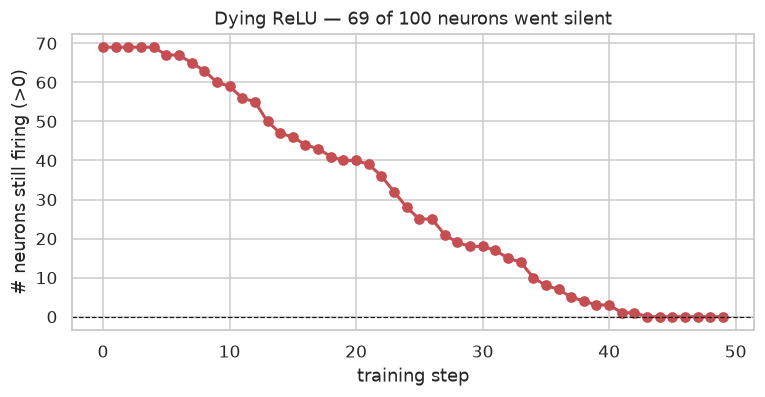

final: 0 of 100 neurons active. Dead neurons waste capacity.


In [2]:
# Simulate: a population of ReLU neurons, some driven negative early, watch them die.
rng = np.random.default_rng(0)
n_neurons = 100
# Neuron pre-activations after some training — bimodal: a chunk are negative
z_init = np.concatenate([rng.normal(-3, 1, 30), # 30 neurons pushed negative
 rng.normal(2, 1, 70)]) # 70 healthy
alive_history = []
z = z_init.copy()
for step in range(50):
 alive = (z > 0).sum()
 alive_history.append(alive)
 # Simulate training: healthy neurons drift toward 0 (learning); dead ones
 # get gradient 0 so never move.
 grad = np.where(z > 0, rng.normal(-0.1, 0.05, n_neurons), 0.0)
 z = z + grad

plt.figure(figsize=(8, 3.5))
plt.plot(alive_history, "o-", color="#c44e52", lw=2)
plt.xlabel("training step"); plt.ylabel("# neurons still firing (>0)")
plt.title(f"Dying ReLU — {alive_history[0] - alive_history[-1]} of {n_neurons} neurons went silent")
plt.axhline(alive_history[-1], color="k", ls="--", lw=0.8)
plt.show()
print(f"final: {alive_history[-1]} of {n_neurons} neurons active. Dead neurons waste capacity.")

> **Diagnostic:** if a big fraction of your activations are zero across many
> inputs, you have dying ReLUs. Cures: **Leaky ReLU / ELU**, a smaller learning
> rate, or **better initialisation** (§4 — He init keeps pre‑activations healthy).

## 2. Loss functions — match the loss to the task

The loss $L$ is the single number gradient descent minimises. Picking the wrong
one trains the model to do the wrong thing.

| Task | Loss | Formula | Notes |
|---|---|---|---|
| **Regression** | **MSE** | $\frac{1}{n}\sum(y-\hat y)^2$ | penalises large errors heavily (squared) |
| **Regression (robust)** | **MAE** | $\frac{1}{n}\sum\lvert y-\hat y\rvert$ | robust to outliers; gradient constant |
| **Binary classification** | **Binary cross‑entropy** | $-[y\log\hat p + (1-y)\log(1-\hat p)]$ | pairs with sigmoid output |
| **Multiclass** | **Categorical cross‑entropy** | $-\sum_k y_k \log \hat p_k$ | pairs with softmax output |
| **Margin / ranking** | **Hinge** | $\max(0, 1 - y\hat y)$ | used by SVMs (notebook 10) |

> **Why cross‑entropy for classification, not MSE?** MSE + sigmoid saturates:
> when the prediction is confidently wrong, the gradient *vanishes* (the model
> stops learning from its worst errors). Cross‑entropy's gradient is
> $\hat p - y$, which stays large exactly when the model is confidently wrong —
> the right behaviour.

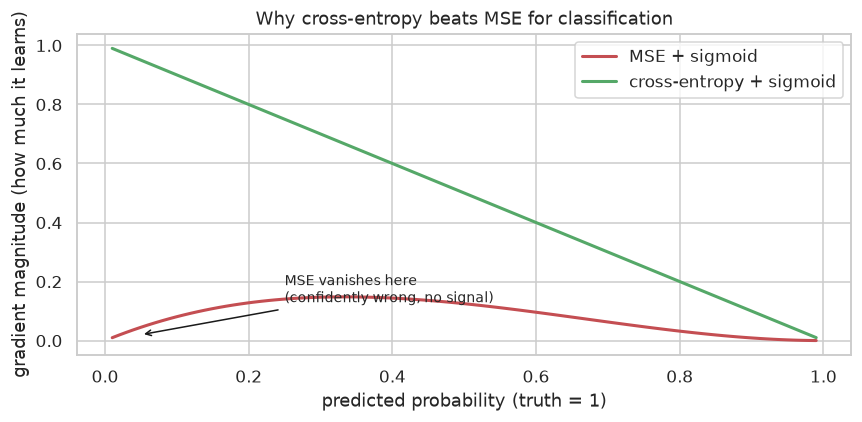

In [3]:
# Visualise: gradient magnitude vs predicted probability, for a wrong (y=1) example.
p_hat = np.linspace(0.01, 0.99, 100)
y_true = 1.0
# MSE + sigmoid gradient magnitude (proportional to |dL/dz|)
mse_grad = np.abs((p_hat - y_true) * p_hat * (1 - p_hat))
# Cross-entropy + sigmoid gradient magnitude
ce_grad = np.abs(p_hat - y_true)

plt.figure(figsize=(8, 4))
plt.plot(p_hat, mse_grad, lw=2, label="MSE + sigmoid", color="#c44e52")
plt.plot(p_hat, ce_grad, lw=2, label="cross-entropy + sigmoid", color="#55a868")
plt.xlabel("predicted probability (truth = 1)")
plt.ylabel("gradient magnitude (how much it learns)")
plt.title("Why cross‑entropy beats MSE for classification")
plt.annotate("MSE vanishes here\n(confidently wrong, no signal)", xy=(0.05, 0.02),
 xytext=(0.25, 0.13), fontsize=9,
 arrowprops=dict(arrowstyle="->", color="k"))
plt.legend(); plt.tight_layout(); plt.show()

**Reading the curves:** when the model predicts ~0 but truth is 1 (confidently
wrong), MSE's gradient collapses to ~0 — **the model can't learn from its worst
mistakes**. Cross‑entropy's gradient is at its maximum there — exactly right.

## 3. Optimisers — SGD → momentum → RMSprop → Adam

All are gradient descent (notebook 14 §2). The question is how to choose the
step. The progression:

### 3.1 Plain SGD
$\theta \leftarrow \theta - \eta \, g_t$

Steps in the direction of the current gradient. Sensitive to the learning rate
and to loss‑surface conditioning (notebook 14 §5).

### 3.2 SGD + momentum
$v_t = \beta v_{t-1} + g_t$, then step by $\eta v_t$.

Accumulates a **velocity** — damps the zig‑zag across ravines and accelerates
along the long valley. The single most useful add‑on to SGD.

### 3.3 RMSprop
$s_t = \beta s_{t-1} + (1-\beta) g_t^2$, step by $\eta \, g_t / (\sqrt{s_t} + \varepsilon)$.

**Per‑parameter adaptive learning rate**: parameters with large recent gradients
get smaller steps, flat ones get bigger steps. Handles uneven curvatures.

### 3.4 Adam — the default
Combines momentum + RMSprop, plus **bias correction** (the moments start at 0):

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$\hat m_t = \frac{m_t}{1-\beta_1^t}, \quad \hat v_t = \frac{v_t}{1-\beta_2^t}, \quad \theta \leftarrow \theta - \eta \frac{\hat m_t}{\sqrt{\hat v_t} + \varepsilon}$$

The bias correction makes the **first step ~ a sign‑based update** of size $\eta$,
so Adam starts fast. Defaults $\beta_1=0.9, \beta_2=0.999, \varepsilon=10^{-8}$.

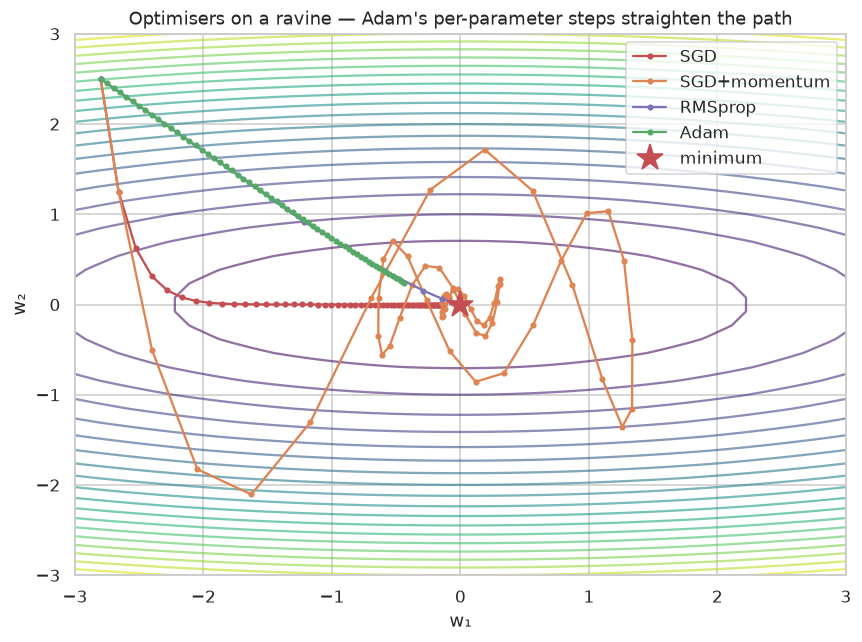

In [4]:
# Compare SGD vs momentum vs Adam on our 2D ravine (poorly-conditioned surface).
def loss_and_grad(theta, stretch=10):
    a, b = theta
    L = 0.5 * (a**2 + stretch * b**2)
    g = np.array([a, stretch * b])
    return L, g

def run(opt_name, n=60, lr=0.05):
    theta = np.array([-2.8, 2.5]); path = [theta.copy()]
    v = np.zeros(2); s = np.zeros(2); m = np.zeros(2)
    b1, b2, eps = 0.9, 0.999, 1e-8
    for t in range(1, n+1):
        _, g = loss_and_grad(theta)
        if opt_name == "SGD":
            theta = theta - lr * g
        elif opt_name == "SGD+momentum":
            v = b1*v + g
            theta = theta - lr * v
        elif opt_name == "RMSprop":
            s = b2*s + (1-b2)*g**2
            theta = theta - lr * g / (np.sqrt(s) + eps)
        elif opt_name == "Adam":
            m = b1*m + (1-b1)*g
            v = b2*v + (1-b2)*g**2
            mhat = m / (1 - b1**t)
            vhat = v / (1 - b2**t)
            theta = theta - lr * mhat / (np.sqrt(vhat) + eps)
        path.append(theta.copy())
    return np.array(path)

A2, B2 = np.meshgrid(np.linspace(-3, 3, 40), np.linspace(-3, 3, 40))
Z = 0.5 * (A2**2 + 10 * B2**2)
fig, ax = plt.subplots(figsize=(8, 6))
ax.contour(A2, B2, Z, 20, cmap="viridis", alpha=0.6)
for name, color in [("SGD", "#c44e52"), ("SGD+momentum", "#dd8452"),
 ("RMSprop", "#8172b3"), ("Adam", "#55a868")]:
 p = run(name, lr=0.05)
 ax.plot(p[:, 0], p[:, 1], "o-", color=color, lw=1.5, ms=3, label=name)
ax.plot(0, 0, "r*", markersize=18, label="minimum")
ax.set_title("Optimisers on a ravine — Adam's per-parameter steps straighten the path")
ax.set_xlabel("w₁"); ax.set_ylabel("w₂"); ax.legend()
plt.tight_layout(); plt.show()

**Reading the paths:**
- **Plain SGD** zig‑zags across the steep wall and crawls along the valley
 (notebook 14 §5, replayed).
- **SGD+momentum** damps the zig‑zag (velocity averages out the bounce).
- **RMSprop** takes big steps along the flat direction, small along the steep
 one — the per‑parameter adaptive rate.
- **Adam** combines both → near‑straight path to the minimum in few steps.

> **Practical guidance:** **Adam** is the right default for most problems (lr
= 0.001). Reach for **SGD+momentum** when you want the absolute best
generalisation on a large net (it often edges Adam there, at the cost of more
tuning). Notebook 09's `MLPClassifier` uses Adam by default.

## 4. Weight initialisation — He for ReLU, Xavier for tanh/sigmoid

Initialise all weights to zero and every neuron in a layer computes the same
thing → they stay identical forever ("symmetry breaking fails"). Initialise
too large and activations explode; too small and they vanish. The right
variance keeps signal magnitude stable layer‑to‑layer.

| Method | For activation | Variance of weights |
|---|---|---|
| **Xavier / Glorot** | tanh, sigmoid | $\mathrm{Var}(W) = \dfrac{2}{\mathrm{fan\_in} + \mathrm{fan\_out}}$ |
| **He / Kaiming** | ReLU (and variants) | $\mathrm{Var}(W) = \dfrac{2}{\mathrm{fan\_in}}$ |

(He doubles the numerator vs Xavier because ReLU zeros out ~half the units,
halving the forward variance.)

In [5]:
# Simulate forward pass through 20 layers and watch activation variance.
def forward_var(init_scale, activation, n_layers=20, fan_in=256, n_trials=50):
    variances = []
    for _ in range(n_trials):
        x = np.random.randn(fan_in) * 0.5
        for _ in range(n_layers):
            W = np.random.randn(fan_in, fan_in) * init_scale
            x = W @ x
            if activation == "relu":
                x = np.maximum(0, x)
            elif activation == "tanh":
                x = np.tanh(x)
        variances.append(np.var(x))
    return np.mean(variances)

fan_in = 256
fan_out = 256
scenarios = [
 ("ReLU + He init", np.sqrt(2/fan_in), "relu"),
 ("ReLU + too small", np.sqrt(0.01/fan_in), "relu"),
 ("ReLU + too large", np.sqrt(100/fan_in), "relu"),
 ("tanh + Xavier", np.sqrt(2/(fan_in+fan_out)), "tanh"),
]
for name, scale, act in scenarios:
 print(f"{name:<22} (init std={scale:.4f}) -> output var after 20 layers = {forward_var(scale, act):.3e}")

ReLU + He init         (init std=0.0884) -> output var after 20 layers = 1.735e-01
ReLU + too small       (init std=0.0063) -> output var after 20 layers = 1.532e-47
ReLU + too large       (init std=0.6250) -> output var after 20 layers = 1.568e+33
tanh + Xavier          (init std=0.0625) -> output var after 20 layers = 2.346e-02


**Reading the output:** with **He/Xavier** the variance stays in a sane range.
**Too small** → variance collapses to ~0 (vanishing signal). **Too large** →
explodes. That's the whole justification for the formulas — they keep the
signal alive through depth.

> **In practice** you rarely set this by hand — `MLPClassifier`, PyTorch, etc.
> all default to He/Xavier. But when a deep net "won't train," checking the
> activation/variance per layer is step one of diagnosis.

## 5. Regularisation — fighting overfitting (§6.2)

Neural nets have huge capacity → high variance → overfit easily (notebook 09 §7,
notebook 14's bias/variance). Four tools, each attacking it differently:

| Method | What it does | When |
|---|---|---|
| **L2 (weight decay)** | add $\lambda \lVert W \rVert^2$ to the loss → shrinks weights | the default; mild, always helps |
| **Dropout** | randomly zero a fraction of activations each step | very effective on big MLPs/CNNs; rare in modern Transformers |
| **Early stopping** | halt when validation loss starts rising | the most universal; always enable |
| **Batch‑norm** | normalise each layer's activations | stabilises deep training; mild regularisation side‑effect |

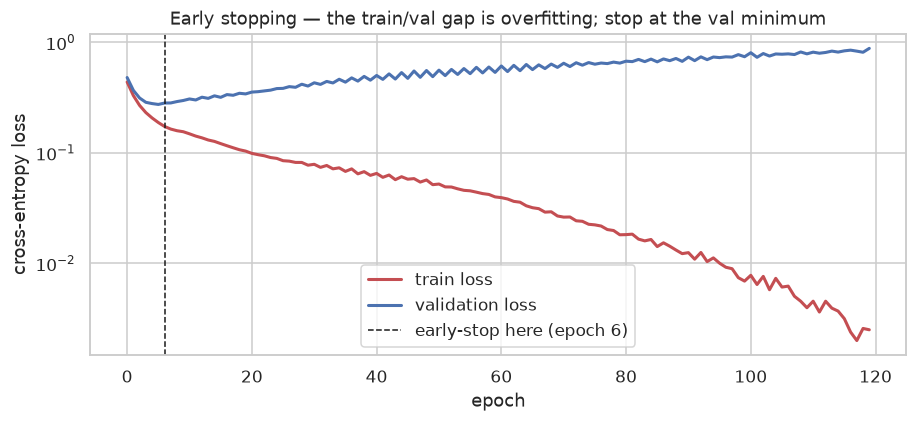

In [6]:
# Demo: early stopping prevents overfitting on a synthetic train/val split.
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=400, n_features=20, n_informative=5,
 n_redundant=10, random_state=0)
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.4, random_state=0)
sc = StandardScaler().fit(Xtr); Xtr, Xv = sc.transform(Xtr), sc.transform(Xv)

# Track train/val loss per epoch (warm_start to continue training).
net = MLPClassifier(hidden_layer_sizes=(128,), max_iter=1, warm_start=True,
 learning_rate_init=0.01, random_state=0,
 early_stopping=False)
from sklearn.metrics import log_loss
tr_losses, v_losses = [], []
for ep in range(120):
 net.fit(Xtr, ytr)
 tr_losses.append(log_loss(ytr, net.predict_proba(Xtr)))
 v_losses.append(log_loss(yv, net.predict_proba(Xv)))

best_ep = np.argmin(v_losses) + 1
plt.figure(figsize=(8.5, 4))
plt.plot(tr_losses, label="train loss", color="#c44e52", lw=2)
plt.plot(v_losses, label="validation loss", color="#4c72b0", lw=2)
plt.axvline(best_ep, color="k", ls="--", lw=1,
 label=f"early‑stop here (epoch {best_ep})")
plt.xlabel("epoch"); plt.ylabel("cross‑entropy loss"); plt.yscale("log")
plt.title("Early stopping — the train/val gap is overfitting; stop at the val minimum")
plt.legend(); plt.tight_layout(); plt.show()

**The textbook early‑stopping picture:** train loss keeps falling; validation
loss falls, hits a minimum, then *rises* — that's overfitting starting. Stop at
the minimum. **In sklearn, set `early_stopping=True`** and it does this
automatically (notebook 09 exercise 2).

> **Combine tools, don't pick one:** in practice you use **L2 + early stopping**
> almost always, plus **dropout/batch‑norm** on bigger architectures. No single
> regulariser is enough; they're complementary.

## Common pitfalls & how to avoid shooting yourself in the foot

1. **Sigmoid/tanh in deep hidden layers (§1.2).** Vanishing gradients (notebook
 14 §4.2). Use ReLU.
2. **Dying ReLUs unmonitored (§1.3).** Check the fraction of zero activations;
 switch to Leaky/ELU if high.
3. **MSE for classification (§2).** Gradient vanishes on confidently‑wrong
 predictions. Use cross‑entropy.
4. **Wrong learning rate for the optimiser (§3).** Adam's default 0.001 is fine;
 SGD needs ~0.01 + momentum. Don't swap optimisers without re‑tuning lr.
5. **Skipping initialisation awareness (§4).** It's automatic in modern libs,
 but if a net won't train, check per‑layer activation variance.
6. **No early stopping (§5).** Training to `max_iter` every time overfits. Turn
 it on by default.
7. **Stacking regularisers without measuring.** Add one, re‑measure CV; don't
 pile them on blind.
8. **Forgetting the baseline (notebook 13).** A net that "trains" but loses to
 logistic regression has the wrong architecture/data, not insufficient depth.

## Exercises

1. **Activation zoo, felt.** Replace the §4 forward‑pass sim's activation with
 sigmoid and run 20 layers. What's the output variance? Now ReLU + He. Why the
 huge difference (link to notebook 14 §4.2)?
2. **Cross‑entropy in action.** On the breast‑cancer dataset, fit two MLPs — one
 with `log_loss` (cross‑entropy, default) and one forced to MSE (manually) —
 for 200 epochs. Which converges faster? Why?
3. **Optimiser swap.** On a digits MLP, swap Adam for SGD (no momentum) at the
 same lr. What happens to the loss curve? Now add momentum — how much does it
 help?
4. **Dying‑ReLU diagnostic.** Fit an MLPClassifier on a noisy dataset and
 inspect the mean activation of each hidden neuron (via `coefs_` /
 `predict_proba` on intermediate — or just count post‑activation zeros). What
 fraction is dead? Refit with a smaller learning rate — does it improve?
5. **Regulariser budget.** On a clearly‑overfitting MLP (val loss rising), add
 L2 only, then dropout only, then early stopping only, then all three. Plot
 val loss for each. Which single one helps most? Which combo?

<details><summary>Answers (click to expand)</summary>

```python
# 1: sigmoid -> output var ~1e-25 (vanishing); ReLU+He -> ~1 (stable). That's
# the vanishing-gradient problem in numbers, and the reason ReLU won.

# 2: Cross-entropy converges in far fewer epochs because its gradient doesn't
# vanish on confidently-wrong predictions (see §2 plot). MSE+sigmoid stalls.

# 3: SGD (no momentum) at Adam's lr=0.001 barely moves (SGD needs ~0.01); with
# momentum it converges but slower than Adam and needs lr tuning. Optimiser
# and lr are coupled — never swap one without re-tuning the other.

# 4: Fraction dead depends on data/lr; often 5-20%. Smaller lr -> fewer dead
# neurons (smaller updates -> less chance of pushing a neuron negative).
# Leaky ReLU eliminates the problem entirely.

# 5: Early stopping usually helps most for the least effort (it's free). The
# combo of all three typically beats any single one -> they're complementary.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — §0
 (bias = intercept collision), §6 (bias/variance — regularisation is the
 variance dial).
- **Notebook 14** — the companion: gradient descent, backprop, the math.
- Kingma & Ba (2014), *Adam: A Method for Stochastic Optimization* — the Adam
 paper (bias‑corrected moments).
- He et al. (2015), *Delving Deep into Rectifiers* — He init and the ReLU family.
- Glorot & Bengio (2010), *Understanding the difficulty of training deep
 feedforward neural networks* — Xavier init.
- Srivastava et al. (2014), *Dropout*; Ioffe & Szegedy (2015), *Batch
 Normalization*.
- Goodfellow, Bengio & Courville (2016), *Deep Learning*, Ch. 6 (MLP), Ch. 8
 (optimisation), Ch. 7 (regularisation): <https://www.deeplearningbook.org/>.